# CMIP6 ACCESS-CM2 Example Download and Plot - New York
This notebook downloads a single CMIP6 model (ACCESS-CM2) for New York using HadCRUT5 gridbox boundaries.

## 1. Import Required Libraries
Import libraries for CDS API, file handling, and plotting.

In [1]:
import sys
import zipfile
from pathlib import Path
from importlib import reload

import cdsapi
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from shapely.geometry import box

import cmip6
reload(cmip6)

from cmip6 import (
    normalize_model_id,
    sanitize_filename,
    sniff_file_type,
    open_dataset_auto,
    combine_experiments,
    combine_historical_with_scenarios,
    generate_year_range,
    compute_anomalies,
    compute_seasonal_anomalies,
    average_tasmax_tasmin,
    process_scenarios_anomalies,
    cleanup_intermediate_files,
 )

/Users/shaleni/Documents/GitHub/Copernicus/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## 2. Define Model Parameters
Choose a model, scenario, and variable to download from CDS.

In [2]:
EXCEL_FILE = "CMIP6_Model_Availability.xlsx"
SHEET_NAME = "Intersection_All_SSPs"

MODEL = "ACCESS-CM2"  # change to any model in the sheet
EXPERIMENTS = ["historical", "ssp126", "ssp245", "ssp585"]
VARIABLE = "tasmin"  # tasmax or tasmin

DOWNLOAD_DIR = Path("CMIP6")
LOCATION = "NewYork"  # Organize downloads by location
DATASET = "projections-cmip6"
TEMPORAL_RESOLUTION = "monthly"
MONTHS = ["01", "02", "03", "04", "05", "06", "07", "08", "09", "10", "11", "12"]
AREA = [45, -75, 40, -70]  # HadCRUT5 gridbox (40-45°N, 70-75°W) containing NYC [N, W, S, E]

VARIABLE_MAP = {
    "tasmax": "daily_maximum_near_surface_air_temperature",
    "tasmin": "daily_minimum_near_surface_air_temperature",
}

EXPERIMENT_API_MAP = {
    "historical": "historical",
    "ssp126": "ssp1_2_6",
    "ssp245": "ssp2_4_5",
    "ssp585": "ssp5_8_5",
}

EXPERIMENT_YEARS = {
    "historical": (1850, 2014),
    "ssp126": (2015, 2300),
    "ssp245": (2015, 2300),
    "ssp585": (2015, 2300),
}

### 2a. Map of New York and CMIP6 Area
Overlay the CMIP6 bounding box for NYC on the NY state outline.

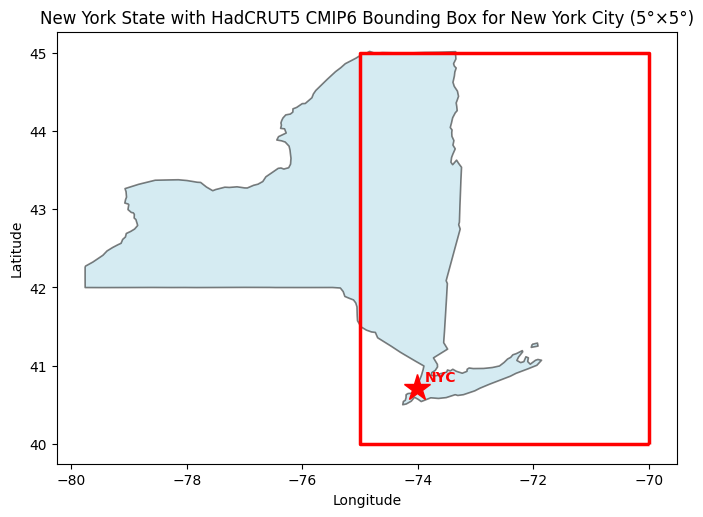

In [3]:
states_url = "https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip"
states = gpd.read_file(states_url)
ny = states[states["NAME"] == "New York"].to_crs("EPSG:4326")

north, west, south, east = AREA
bbox = box(west, south, east, north)
bbox_gdf = gpd.GeoSeries([bbox], crs="EPSG:4326")

# New York City coordinates
nyc_lat, nyc_lon = 40.7128, -74.0060

ax = ny.plot(figsize=(8, 8), color="lightblue", edgecolor="black", linewidth=1.2, alpha=0.5)
bbox_gdf.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2.5, label="HadCRUT5 gridbox")

# Plot NYC
ax.plot(nyc_lon, nyc_lat, "r*", markersize=20, label="New York City", zorder=5)
ax.annotate("NYC", xy=(nyc_lon, nyc_lat), xytext=(5, 5), textcoords="offset points", 
            fontsize=10, fontweight="bold", color="red")

ax.set_title("New York State with HadCRUT5 CMIP6 Bounding Box for New York City (5°×5°)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 3. Download Model Artifact
Retrieve a single model and it's historical, SSP126, SSP245, and SSP585 scenarios from CDS using cdsapi.

In [4]:
def read_availability(path: str, sheet: str):
    df = pd.read_excel(path, sheet_name=sheet)
    required = {"Model", "tasmax", "tasmin"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {', '.join(sorted(missing))}")
    return df

df_availability = read_availability(EXCEL_FILE, SHEET_NAME)

if VARIABLE not in VARIABLE_MAP:
    raise ValueError(f"Unsupported variable: {VARIABLE}")

for exp in EXPERIMENTS:
    if exp not in EXPERIMENT_API_MAP:
        raise ValueError(f"Unsupported experiment: {exp}")
    if exp not in EXPERIMENT_YEARS:
        raise ValueError(f"Missing years for experiment: {exp}")

if MODEL not in df_availability["Model"].values:
    raise ValueError(f"Model not found in sheet: {MODEL}")

availability_value = df_availability.set_index("Model")[VARIABLE].get(MODEL, "")
if str(availability_value).lower() != "available":
    raise ValueError(f"{MODEL} {VARIABLE} is not marked Available in the sheet")

model_id = normalize_model_id(MODEL)
file_model = sanitize_filename(MODEL)
variable_name = VARIABLE_MAP[VARIABLE]
model_dir = DOWNLOAD_DIR / LOCATION / file_model  # Organize by location then model
model_dir.mkdir(parents=True, exist_ok=True)

client = cdsapi.Client()
LOCAL_PATH = None

for exp in EXPERIMENTS:
    start_year, end_year = EXPERIMENT_YEARS[exp]
    api_experiment = EXPERIMENT_API_MAP[exp]

    output_name = f"cmip6_{VARIABLE}_{file_model}_{exp}_{start_year}-{end_year}.nc"
    LOCAL_PATH = model_dir / output_name

    if LOCAL_PATH.exists():
        print(f"File already exists, skipping: {LOCAL_PATH}")
        continue

    request = {
        "temporal_resolution": TEMPORAL_RESOLUTION,
        "experiment": api_experiment,
        "variable": variable_name,
        "model": model_id,
        "month": MONTHS,
        "year": generate_year_range(start_year, end_year),
        "area": AREA,
        "format": "netcdf",
    }

    result = client.retrieve(DATASET, request)
    result.download(str(LOCAL_PATH))
    print(f"Downloaded: {output_name}")

File already exists, skipping: CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_historical_1850-2014.nc
File already exists, skipping: CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_ssp126_2015-2300.nc
File already exists, skipping: CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_ssp245_2015-2300.nc
File already exists, skipping: CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_ssp585_2015-2300.nc


## 4. Load Model Metadata
Load metadata from the last downloaded NetCDF.

In [5]:
if LOCAL_PATH.exists():
    ds = open_dataset_auto(LOCAL_PATH, download_dir=model_dir)
    print(ds)
    print("Variables:", list(ds.data_vars))
else:
    ds = None
    print("File not found. Download first.")

<xarray.Dataset> Size: 74kB
Dimensions:    (time: 1032, bnds: 2, lat: 4, lon: 3)
Coordinates:
  * time       (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T1...
  * lat        (lat) float64 32B 40.62 41.88 43.12 44.38
  * lon        (lon) float64 24B 285.9 287.8 289.7
    height     float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 17kB ...
    lat_bnds   (lat, bnds) float64 64B ...
    lon_bnds   (lon, bnds) float64 48B ...
    tasmin     (time, lat, lon) float32 50kB ...
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T03:12:28Z
    ...                     ...
    variable_id:            tasmin
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    track

In [6]:
print("\nDataset Time Ranges:")
print("=" * 60)

for exp in EXPERIMENTS:
    start_year, end_year = EXPERIMENT_YEARS[exp]
    output_name = f"cmip6_{VARIABLE}_{file_model}_{exp}_{start_year}-{end_year}.nc"
    exp_path = model_dir / output_name

    if exp_path.exists():
        try:
            ds_exp = open_dataset_auto(exp_path)
            time_var = ds_exp.time
            time_min = pd.Timestamp(time_var.values[0]).year
            time_max = pd.Timestamp(time_var.values[-1]).year
            n_timesteps = len(time_var)
            print(f"{exp:12s}: {time_min} - {time_max} ({n_timesteps} timesteps)")
        except Exception as e:
            print(f"{exp:12s}: Error reading time - {e}")
    else:
        print(f"{exp:12s}: File not found")

print("=" * 60)


Dataset Time Ranges:
historical  : 1850 - 2014 (1980 timesteps)
ssp126      : 2015 - 2100 (1032 timesteps)
ssp245      : 2015 - 2100 (1032 timesteps)
ssp585      : 2015 - 2100 (1032 timesteps)


## 5. Plot Model Summary
Plot a time series of the spatial mean for the chosen variable.

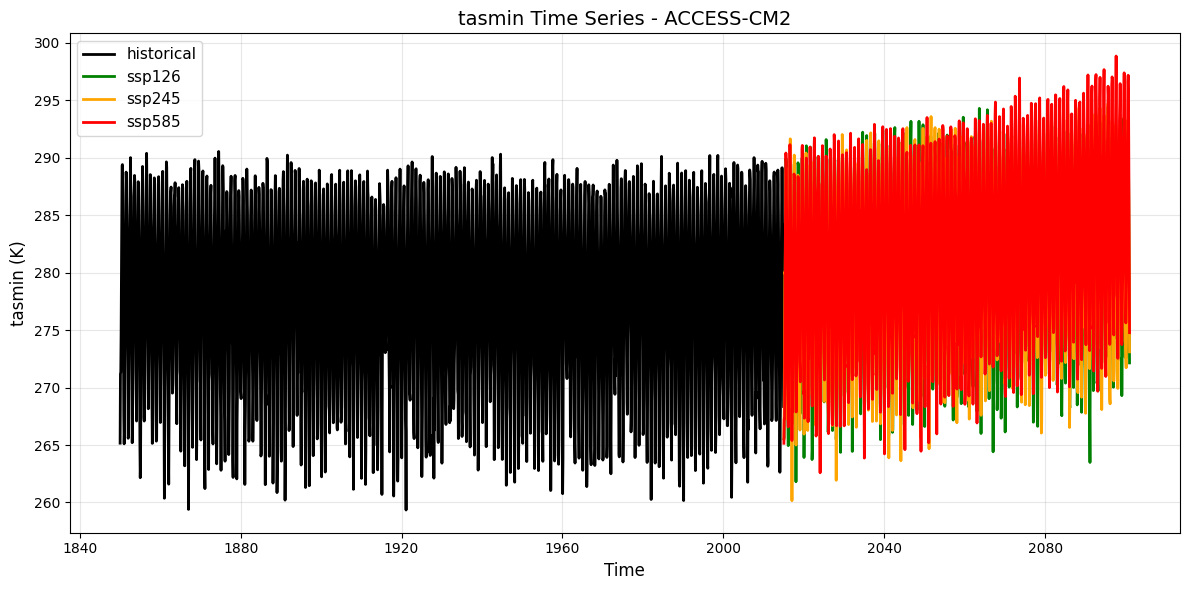

In [33]:
color_map = {
    "historical": "black",
    "ssp126": "green",
    "ssp245": "orange",
    "ssp585": "red",
}

fig, ax = plt.subplots(figsize=(12, 6))

for exp in EXPERIMENTS:
    start_year, end_year = EXPERIMENT_YEARS[exp]
    output_name = f"cmip6_{VARIABLE}_{file_model}_{exp}_{start_year}-{end_year}.nc"
    exp_path = model_dir / output_name

    if exp_path.exists():
        try:
            ds_exp = open_dataset_auto(exp_path)
            var_name = VARIABLE
            if var_name not in ds_exp.data_vars:
                var_name = list(ds_exp.data_vars)[0]
            da_exp = ds_exp[var_name]
            spatial_dims = [d for d in da_exp.dims if d != "time"]
            if "time" in da_exp.dims:
                series = da_exp.mean(dim=spatial_dims) if spatial_dims else da_exp
                series.plot(ax=ax, label=exp, color=color_map.get(exp, "gray"), linewidth=2)
        except Exception as e:
            print(f"Error loading {exp}: {e}")
    else:
        print(f"File not found for {exp}: {exp_path}")

ax.set_title(f"{VARIABLE} Time Series - {MODEL}", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel(f"{VARIABLE} (K)", fontsize=12)
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5a. Combine All Experiments into Single File
Merge historical and all scenario data into one NetCDF file.

In [34]:
combine_experiments(model_dir, VARIABLE, file_model, EXPERIMENT_YEARS)

Loaded historical: 1980 timesteps
Loaded ssp126: 1032 timesteps
Loaded ssp245: 1032 timesteps
Loaded ssp585: 1032 timesteps

✓ Combined file saved: CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_combined_1850-2300.nc
  Total timesteps: 5076
  Time range: 1850 - 2100


PosixPath('CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_combined_1850-2300.nc')

## 6. Combine Historical with Each Scenario

For each SSP scenario, combine it with historical data to create continuous timelines (historical+ssp126, historical+ssp245, historical+ssp585).

In [35]:
# Combine historical with each SSP scenario for both tasmax and tasmin
model_dir = DOWNLOAD_DIR / LOCATION / file_model

print("Combining tasmax files:")
combine_historical_with_scenarios(model_dir, "tasmax", file_model, EXPERIMENT_YEARS)

print("\nCombining tasmin files:")
combine_historical_with_scenarios(model_dir, "tasmin", file_model, EXPERIMENT_YEARS)

Combining tasmax files:
Loaded historical: 1980 timesteps
Loaded ssp126: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp126_1850-2300.nc
  Total timesteps: 3012
Loaded ssp245: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp245_1850-2300.nc
  Total timesteps: 3012
Loaded ssp585: 1032 timesteps
✓ Saved cmip6_tasmax_ACCESS-CM2_historical+ssp585_1850-2300.nc
  Total timesteps: 3012

Combining tasmin files:
Loaded historical: 1980 timesteps
Loaded ssp126: 1032 timesteps
✓ Saved cmip6_tasmin_ACCESS-CM2_historical+ssp126_1850-2300.nc
  Total timesteps: 3012
Loaded ssp245: 1032 timesteps
✓ Saved cmip6_tasmin_ACCESS-CM2_historical+ssp245_1850-2300.nc
  Total timesteps: 3012
Loaded ssp585: 1032 timesteps
✓ Saved cmip6_tasmin_ACCESS-CM2_historical+ssp585_1850-2300.nc
  Total timesteps: 3012


[PosixPath('CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_historical+ssp126_1850-2300.nc'),
 PosixPath('CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_historical+ssp245_1850-2300.nc'),
 PosixPath('CMIP6/NewYork/ACCESS-CM2/cmip6_tasmin_ACCESS-CM2_historical+ssp585_1850-2300.nc')]

## 7. Compute Anomalies and Average for Each Scenario

For each scenario timeline, compute anomalies relative to 1961-1990 baseline and average tasmax+tasmin.

In [36]:
# Process each scenario (ssp126, ssp245, ssp585)
scenarios = ["ssp126", "ssp245", "ssp585"]

results = process_scenarios_anomalies(
    model_dir=model_dir,
    file_model=file_model,
    scenarios=scenarios,
    baseline_start_year=1961,
    baseline_end_year=1990,
    months=[6, 7, 8],  # JJA
)

scenario_datasets = results["monthly"]
scenario_jja_datasets = results["seasonal"]

print(f"\n{'='*60}")
print(f"Completed processing {len(scenario_datasets)} scenarios")
print('='*60)

✓ Computed anomalies for tasmax (baseline: 1961-1990)
✓ Computed anomalies for tasmin (baseline: 1961-1990)
✓ Computed average temperature (tasmax + tasmin) / 2
✓ Saved cmip6_ACCESS-CM2_temperature_anomalies_historical+ssp126_1961-1990baseline.nc
✓ Computed average temperature (tasmax + tasmin) / 2
✓ Computed seasonal anomalies for temperature (months: [6, 7, 8], baseline: 1961-1990)
✓ Saved cmip6_ACCESS-CM2_temperature_anomalies_JJA_historical+ssp126_1961-1990baseline.nc
✓ Computed anomalies for tasmax (baseline: 1961-1990)
✓ Computed anomalies for tasmin (baseline: 1961-1990)
✓ Computed average temperature (tasmax + tasmin) / 2
✓ Saved cmip6_ACCESS-CM2_temperature_anomalies_historical+ssp245_1961-1990baseline.nc
✓ Computed average temperature (tasmax + tasmin) / 2
✓ Computed seasonal anomalies for temperature (months: [6, 7, 8], baseline: 1961-1990)
✓ Saved cmip6_ACCESS-CM2_temperature_anomalies_JJA_historical+ssp245_1961-1990baseline.nc
✓ Computed anomalies for tasmax (baseline: 196

### 7a. Plot Temperature Anomalies by Scenario

Plot the averaged temperature anomalies for each scenario (each includes historical baseline period).

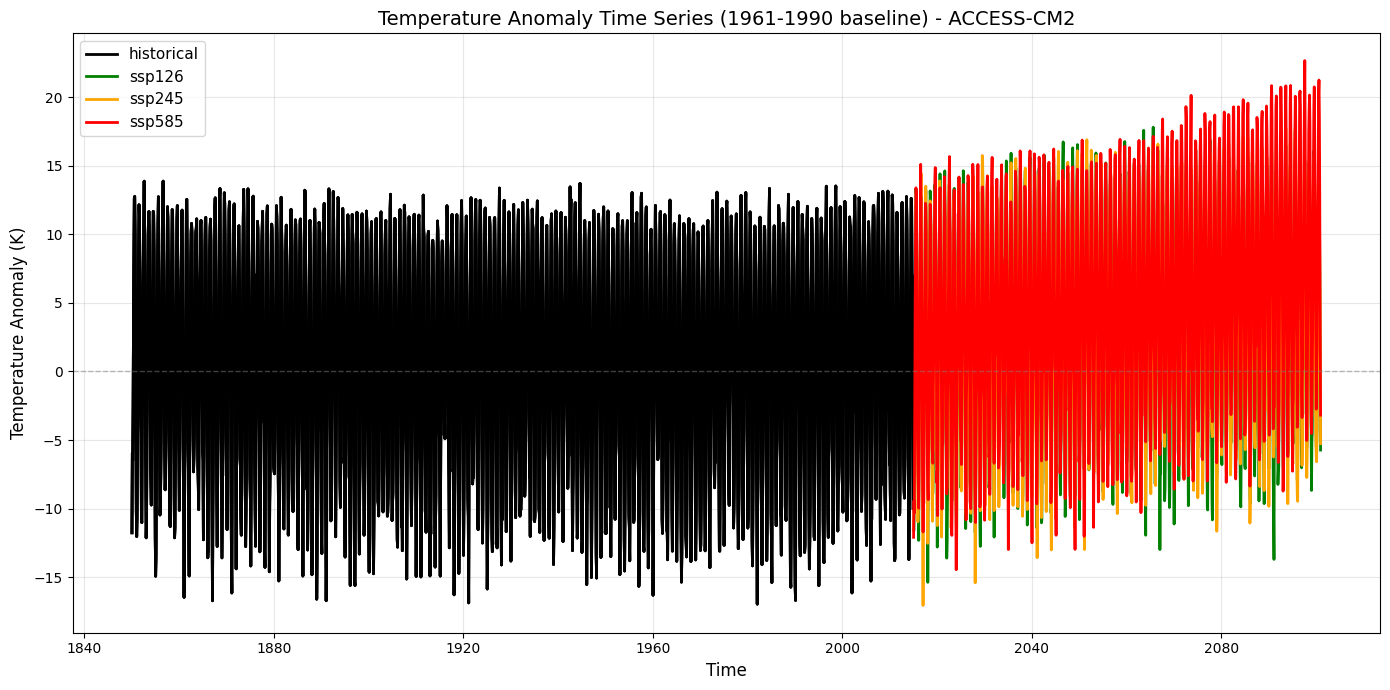

In [37]:
color_map = {
    "ssp126": "green",
    "ssp245": "orange",
    "ssp585": "red",
}

fig, ax = plt.subplots(figsize=(14, 7))

# Track if we've already plotted historical to avoid duplicate labels
historical_plotted = False

# Plot each scenario
for scenario, ds in scenario_datasets.items():
    # Get the temperature variable
    var_name = 'temperature' if 'temperature' in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var_name]
    
    # Compute spatial mean
    spatial_dims = [d for d in da.dims if d != 'time']
    if spatial_dims:
        series = da.mean(dim=spatial_dims)
    else:
        series = da
    
    # Split into historical (before 2015) and SSP (2015 onwards)
    historical = series.sel(time=series.time.dt.year < 2015)
    ssp = series.sel(time=series.time.dt.year >= 2015)
    
    # Plot historical in black (only label once)
    if not historical_plotted:
        historical.plot(ax=ax, label="historical", color="black", linewidth=2)
        historical_plotted = True
    else:
        historical.plot(ax=ax, color="black", linewidth=2)
    
    # Plot SSP in scenario-specific color
    ssp.plot(ax=ax, label=scenario, color=color_map.get(scenario, "gray"), linewidth=2)

ax.set_title(f"Temperature Anomaly Time Series (1961-1990 baseline) - {MODEL}", fontsize=14)
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Temperature Anomaly (K)", fontsize=12)
ax.legend(loc="best", fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

### 7b. Side-by-Side: Full Anomalies vs JJA Anomalies
Compare the full (month-level) anomaly series to the JJA anomaly series.

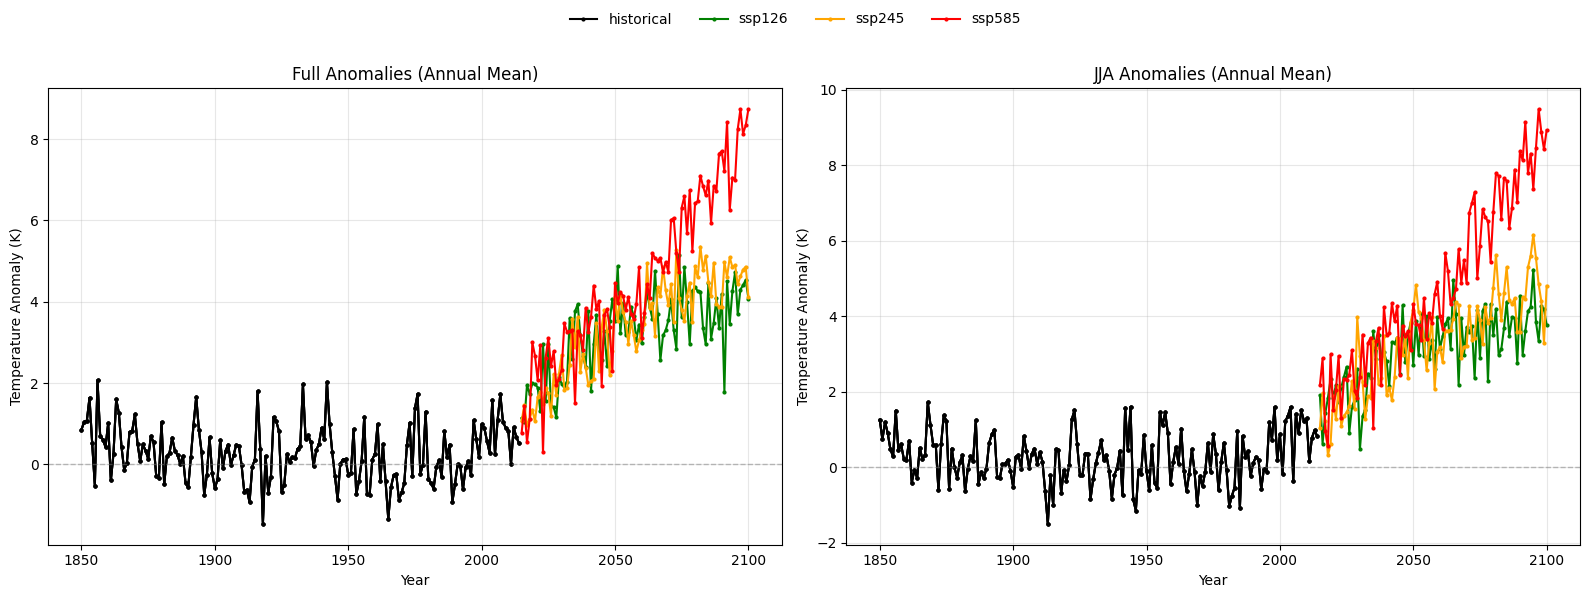

In [ ]:
color_map = {
    "ssp126": "green",
    "ssp245": "orange",
    "ssp585": "red",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# Left: full anomalies, annual mean
historical_plotted = False
for scenario, ds in scenario_datasets.items():
    var_name = 'temperature' if 'temperature' in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var_name]
    spatial_dims = [d for d in da.dims if d != 'time']
    series = da.mean(dim=spatial_dims) if spatial_dims else da
    annual = series.groupby('time.year').mean()
    historical = annual.sel(year=annual.year < 2015)
    ssp = annual.sel(year=annual.year >= 2015)
    if not historical_plotted:
        historical.plot(ax=ax1, label="historical", color="black", linewidth=1.5, marker='o', markersize=2)
        historical_plotted = True
    else:
        historical.plot(ax=ax1, color="black", linewidth=1.5, marker='o', markersize=2)
    ssp.plot(ax=ax1, label=scenario, color=color_map.get(scenario, "gray"), linewidth=1.5, marker='o', markersize=2)

ax1.set_title("Full Anomalies (Annual Mean)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature Anomaly (K)")
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Right: JJA anomalies (yearly)
historical_plotted = False
for scenario, ds in scenario_jja_datasets.items():
    var_name = 'temperature' if 'temperature' in ds.data_vars else list(ds.data_vars)[0]
    da = ds[var_name]
    spatial_dims = [d for d in da.dims if d != 'year']
    series = da.mean(dim=spatial_dims) if spatial_dims else da
    historical = series.sel(year=series.year < 2015)
    ssp = series.sel(year=series.year >= 2015)
    if not historical_plotted:
        historical.plot(ax=ax2, label="historical", color="black", linewidth=1.5, marker='o', markersize=2)
        historical_plotted = True
    else:
        historical.plot(ax=ax2, color="black", linewidth=1.5, marker='o', markersize=2)
    ssp.plot(ax=ax2, label=scenario, color=color_map.get(scenario, "gray"), linewidth=1.5, marker='o', markersize=2)

ax2.set_title("JJA Anomalies (Annual Mean)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Temperature Anomaly (K)")
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 8. Clean Up Intermediate Files

Remove intermediate combined files, keeping only original downloaded files and the final scenario anomaly files.

In [7]:
cleanup_intermediate_files(model_dir, file_model)

print("\n" + "="*60)
print("Final files in directory:")
print("="*60)
for f in sorted(model_dir.glob("*.nc")):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name} ({size_mb:.1f} MB)")
print("="*60)


  Removed: tasmin_Amon_ACCESS-CM2_ssp126_r1i1p1f1_gn_20150116-21001216.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_historical+ssp245_1961-1990baseline.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_JJA_historical+ssp245_1961-1990baseline.nc
  Removed: tasmin_Amon_ACCESS-CM2_historical_r1i1p1f1_gn_18500116-20141216.nc
  Removed: tasmin_Amon_ACCESS-CM2_ssp245_r1i1p1f1_gn_20150116-21001216.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_historical+ssp585_1961-1990baseline.nc
  Removed: tasmin_Amon_ACCESS-CM2_ssp585_r1i1p1f1_gn_20150116-21001216.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_JJA_historical+ssp585_1961-1990baseline.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_JJA_historical+ssp126_1961-1990baseline.nc
  Removed: cmip6_ACCESS-CM2_temperature_anomalies_historical+ssp126_1961-1990baseline.nc
✓ Cleaned up 10 intermediate file(s)

Final files in directory:
  cmip6_ACCESS-CM2_temperature_anomalies_JJA_all_scenarios_1961-1990baseline.nc (0.1 MB)
 